# Executive Summary

### Analysis Overview
- Dataset: 98,619 flights across 235 countries (2022), you can find in https://www.kaggle.com/datasets/iamsouravbanerjee/airline-dataset/data
- Scope: PHASE 1 - Exploratory & Diagnostic Analysis
- Next Phase: Predictive modeling + for root cause analysis (requires extended data)
- Key Finding: 66% of flights delayed/cancelled (critical operational gap)

### Current Analysis

- Data quality assessment
- Temporal trends (monthly, daily patterns)
- Geographic segmentation
- Top 20 detractor airports identified

### Structure

### Glossary

# Import Files

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/airline-dataset")

print("Path to dataset files:", path)

C:\Users\guslu\anaconda3\envs\Anaconda3_14\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\guslu\.cache\kagglehub\datasets\iamsouravbanerjee\airline-dataset\versions\4


In [2]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats # statistics
from statsmodels.tsa.seasonal import seasonal_decompose # time series
from statsmodels.tsa.stattools import adfuller # time series

In [3]:
# Main Dataset
data = pd.read_csv(f'{path}\\Airline Dataset Updated - v2.csv')
data.head(3)

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Fransisco Hazeldine,On Time
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Marla Parsonage,On Time
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Rhonda Amber,On Time


In [4]:
# Transform into DataFrame
df = pd.DataFrame(data)

# Feature Engineering

In [5]:
# Add Age_Range column based on the Age
conditions = [df['Age'] < 18, (df['Age'] >= 18) & (df['Age'] < 60), df['Age'] >= 60]
values = ['Young', 'Adult', 'Elderly']

df['Age_Range'] = np.select(conditions, values, default='Others')

In [6]:
## for use when you need to retrieve destination airport codes.
## Unique Arrival_Airport
## Arrival_Airport = pd.DataFrame(df['Arrival Airport'].unique(),columns=['Column1'])
## Arrival_Airport.to_excel('Arrival_Airport.xlsx', sheet_name='Page1', index=False)

In [7]:
# Support Table fill out with Gen IA with Unique Arrival_Airport
air_dest_data = pd.read_excel(f'{path}\\Arrival_Airport_enriched.xlsx')
air_dest_data.head(3)

,Code,State/Province (UF),Country (English),Continent,Continent Code,Confianca
0,CXF,AK,United States,North America,NAM,Alta
1,YCO,NU,Canada,North America,NAM,Alta
2,GNB,IS,France,Europe,EU,Alta


In [8]:
# Clean air_dest_data
## transfom into Dataframe
air_dest = pd.DataFrame(air_dest_data)

## Remove Confianca column
air_dest = air_dest.drop(columns=['Confianca'])

## Rename Columns
air_dest = air_dest.rename(columns={"Code": "Arrival Airport", "State/Province (UF)": "Airport Country Destination Code",
                                    "Country (English)": "Country Destination Name", "Continent": "Continent Destination",
                                    "Continent Code": "Continent Destination Code"})

In [9]:
# Join Main Dataset with air_dest_data support table on Arrival Airport column
df_final = pd.merge(df, air_dest, on="Arrival Airport", how="left")
df_final.head(3)

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status,Age_Range,Airport Country Destination Code,Country Destination Name,Continent Destination,Continent Destination Code
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Fransisco Hazeldine,On Time,Elderly,AK,United States,North America,NAM
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Marla Parsonage,On Time,Elderly,NU,Canada,North America,NAM
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Rhonda Amber,On Time,Elderly,IS,France,Europe,EU


### Look Over

In [10]:
# Original main dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Passenger ID          98619 non-null  str  
 1   First Name            98619 non-null  str  
 2   Last Name             98619 non-null  str  
 3   Gender                98619 non-null  str  
 4   Age                   98619 non-null  int64
 5   Nationality           98619 non-null  str  
 6   Airport Name          98619 non-null  str  
 7   Airport Country Code  98619 non-null  str  
 8   Country Name          98619 non-null  str  
 9   Airport Continent     98619 non-null  str  
 10  Continents            98619 non-null  str  
 11  Departure Date        98619 non-null  str  
 12  Arrival Airport       98619 non-null  str  
 13  Pilot Name            98619 non-null  str  
 14  Flight Status         98619 non-null  str  
 15  Age_Range             98619 non-null  str  
dtypes: int64(1), st

In [11]:
# Final main dataset
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Passenger ID                      98619 non-null  str  
 1   First Name                        98619 non-null  str  
 2   Last Name                         98619 non-null  str  
 3   Gender                            98619 non-null  str  
 4   Age                               98619 non-null  int64
 5   Nationality                       98619 non-null  str  
 6   Airport Name                      98619 non-null  str  
 7   Airport Country Code              98619 non-null  str  
 8   Country Name                      98619 non-null  str  
 9   Airport Continent                 98619 non-null  str  
 10  Continents                        98619 non-null  str  
 11  Departure Date                    98619 non-null  str  
 12  Arrival Airport                   98619 non

In [12]:
# Treat Data column
df_final['Departure Date'] = df_final['Departure Date'].str.replace('-','/')

df_final['Departure Date'] = pd.to_datetime(df_final['Departure Date'])

print(df.dtypes)

Passenger ID              str
First Name                str
Last Name                 str
Gender                    str
Age                     int64
Nationality               str
Airport Name              str
Airport Country Code      str
Country Name              str
Airport Continent         str
Continents                str
Departure Date            str
Arrival Airport           str
Pilot Name                str
Flight Status             str
Age_Range                 str
dtype: object


In [13]:
# Treat missing values
columns = ["Airport Country Destination Code", "Country Destination Name", "Continent Destination", 
           "Continent Destination Code"]

df_final[columns] = df_final[columns].fillna('N/A')

In [14]:
# Add count column
df_final['count'] = 1
df_final.head(3)

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,Departure Date,Arrival Airport,Pilot Name,Flight Status,Age_Range,Airport Country Destination Code,Country Destination Name,Continent Destination,Continent Destination Code,count
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,...,2022-06-28,CXF,Fransisco Hazeldine,On Time,Elderly,AK,United States,North America,NAM,1
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,2022-12-26,YCO,Marla Parsonage,On Time,Elderly,NU,Canada,North America,NAM,1
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,...,2022-01-18,GNB,Rhonda Amber,On Time,Elderly,IS,France,Europe,EU,1


In [15]:
# final main dataset Treated
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Passenger ID                      98619 non-null  str           
 1   First Name                        98619 non-null  str           
 2   Last Name                         98619 non-null  str           
 3   Gender                            98619 non-null  str           
 4   Age                               98619 non-null  int64         
 5   Nationality                       98619 non-null  str           
 6   Airport Name                      98619 non-null  str           
 7   Airport Country Code              98619 non-null  str           
 8   Country Name                      98619 non-null  str           
 9   Airport Continent                 98619 non-null  str           
 10  Continents                        98619 non-null  str    

# Exploratory data analysis (EDA) 

### Statistics from dataset

In [16]:
# Statistics from column numbers
df_final.describe(include = ['number'])

,Age,count
count,98619.000000,98619.0
mean,45.504021,1.0
std,25.929849,0.0
min,1.000000,1.0
25%,23.000000,1.0
50%,46.000000,1.0
75%,68.000000,1.0
max,90.000000,1.0


In [17]:
# Statistics from column categoricals
df_final.describe(include = ['object', 'category'])

C:\Users\guslu\AppData\Local\Temp\ipykernel_6988\641842075.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_final.describe(include = ['object', 'category'])


,Passenger ID,First Name,Last Name,Gender,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Arrival Airport,Pilot Name,Flight Status,Age_Range,Airport Country Destination Code,Country Destination Name,Continent Destination,Continent Destination Code
count,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619,98619
unique,98619,8437,41658,2,240,9062,235,235,6,6,9024,98605,3,3,531,242,9,9
top,ABVWIg,Gale,Dyball,Male,China,San Pedro Airport,US,United States,NAM,North America,0,Valeda Pratty,Cancelled,Adult,AK,United States,North America,NAM
freq,1,37,17,49598,18317,43,22104,22104,32033,32033,873,2,32942,46200,3691,22326,32603,32603


### Missing Data

In [18]:
# Unknows Destinations
ArAirport_0 = df_final[df_final['Arrival Airport'].isin({'0', '-', 'BR-', 'SB2', 'O62', 'TR7'})]

# Unknows Destinations represents 0,01% from the total 
frequency_0 = ArAirport_0.groupby(pd.Grouper(key='Departure Date', freq='ME')).size().reset_index(name='frequency')
print(f'Total rowns missing: {ArAirport_0.shape[0]} rows')
print(frequency_0)

Total rowns missing: 926 rows
   Departure Date  frequency
0      2022-01-31         93
1      2022-02-28         69
2      2022-03-31         76
3      2022-04-30         71
4      2022-05-31         90
5      2022-06-30         74
6      2022-07-31         76
7      2022-08-31         82
8      2022-09-30         65
9      2022-10-31         83
10     2022-11-30         80
11     2022-12-31         67


In [19]:
print("--- Data Quality Analysis ---")

# 2. Identify which airports are associated with more than one country.
airports_with_multiple_countries = df_final.groupby('Airport Name')['Country Name'].nunique()
invalid_airports = airports_with_multiple_countries[airports_with_multiple_countries > 1].index

# 3. Filter the original DataFrame to retrieve the rows for these airports.
invalid_lines = df_final[df_final['Airport Name'].isin(invalid_airports)]

# 4. Count the number of affected rows
total_invalid_lines = len(invalid_lines)

print(f"Total number of rows with inconsistencies: {total_invalid_lines}")
print("\nAffected lines:")
## Use the following code wisely.
## print(invalid_lines)

--- Data Quality Analysis ---
Total number of rows with inconsistencies: 923

Affected lines:


In [20]:
# In case to analyze per continente, consider removing the missing data
df_final_clean = df_final.query(
    "`Airport Name` not in @invalid_airports and `Arrival Airport` not in @ArAirport_0"
)
df_final_clean.shape

(97696, 21)

### Checking normality

In [21]:
# Grouping data per month
freq_df_final = df_final.groupby(pd.Grouper(key='Departure Date', freq='ME')).size().reset_index(name='frequency')
print(freq_df_final)

   Departure Date  frequency
0      2022-01-31       8416
1      2022-02-28       7653
2      2022-03-31       8431
3      2022-04-30       7959
4      2022-05-31       8496
5      2022-06-30       8128
6      2022-07-31       8451
7      2022-08-31       8544
8      2022-09-30       8149
9      2022-10-31       8415
10     2022-11-30       8053
11     2022-12-31       7924


C:\Users\guslu\AppData\Local\Temp\ipykernel_6988\960054098.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(freq_df_final['frequency'])


<Axes: title={'center': 'Total Passengers'}, xlabel='Passengers', ylabel='Density'>

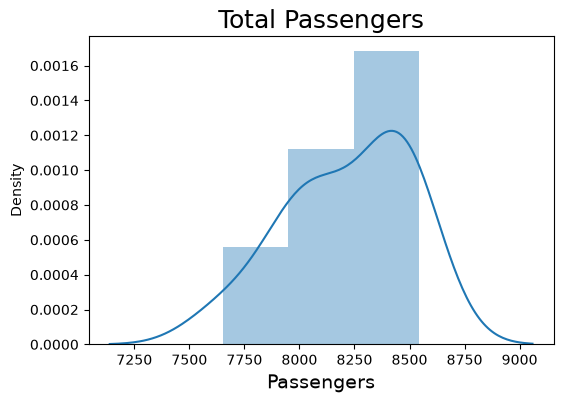

In [22]:
# Density graph to check normality
ax = sns.distplot(freq_df_final['frequency'])
ax.figure.set_size_inches(6, 4)
ax.set_title('Total Passengers', fontsize=18)
ax.set_xlabel('Passengers', fontsize=14)
ax

In [23]:
# Applying the Shapiro-Wilk test
statistic, p_value = stats.shapiro(freq_df_final['frequency'])

print(f"Test statistic: {statistic:.4f}")
print(f"Value p: {p_value:.4f}")

if p_value > 0.05:
    print("The distribution is normal (fail to reject H0).")
else:
    print("The distribution is not normal (reject H0).")

Test statistic: 0.9024
Value p: 0.1705
The distribution is normal (fail to reject H0).


### Time Series

In [24]:
time_series = (
    df_final.groupby(pd.Grouper(key='Departure Date', freq='D')).size().reset_index(name='frequency')
)
print(time_series)

    Departure Date  frequency
0       2022-01-01        267
1       2022-01-02        249
2       2022-01-03        252
3       2022-01-04        267
4       2022-01-05        271
..             ...        ...
359     2022-12-26        262
360     2022-12-27        248
361     2022-12-28        241
362     2022-12-29        240
363     2022-12-30        253

[364 rows x 2 columns]


C:\Users\guslu\AppData\Local\Temp\ipykernel_6988\622367375.py:1: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decompose = seasonal_decompose(time_series['frequency'], extrapolate_trend = 'freq', period = 30).plot()


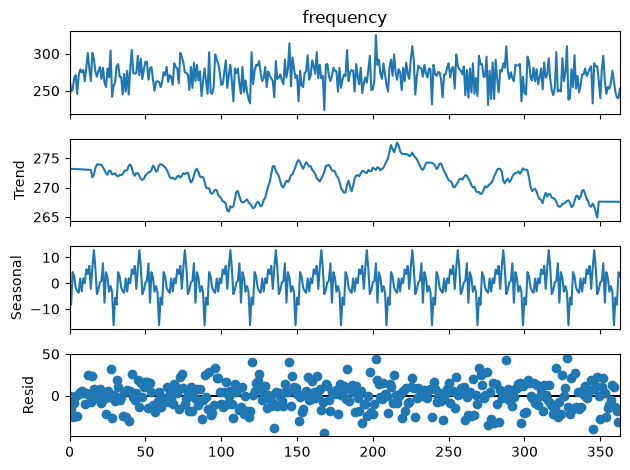

In [25]:
decompose = seasonal_decompose(time_series['frequency'], extrapolate_trend = 'freq', period = 30).plot()

In [26]:
# Checking if the time series is stationary
# If p< 0.05 ; Data is stationary
# If p> 0.05; Data is not stationary

result = adfuller(time_series['frequency'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] < 0.05:
    print(f'Reject the null hypothesis. The series is stationary.')
else: 
    print(f'do not reject the null hypothesis. The series is non-stationary.')

ADF Statistic: -19.521222191592127
p-value: 0.0
Critical Values:
   1%: -3.448493650810824
   5%: -2.8695352280356556
   10%: -2.5710293341377715
Reject the null hypothesis. The series is stationary.


C:\Users\guslu\AppData\Local\Temp\ipykernel_6988\2208149533.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(time_series['frequency'])


### Volume Analysis

In [27]:
# Getting the Average
average = freq_df_final['frequency'].mean()
average

np.float64(8218.25)

In [28]:
# Create a column with color (green if >= average, red if < average)
freq_df_final['color'] = freq_df_final['frequency'].apply(
    lambda x: '#2ecc71' if x >= average else '#e74c3c'
)
print(freq_df_final.head(5))

  Departure Date  frequency    color
0     2022-01-31       8416  #2ecc71
1     2022-02-28       7653  #e74c3c
2     2022-03-31       8431  #2ecc71
3     2022-04-30       7959  #e74c3c
4     2022-05-31       8496  #2ecc71


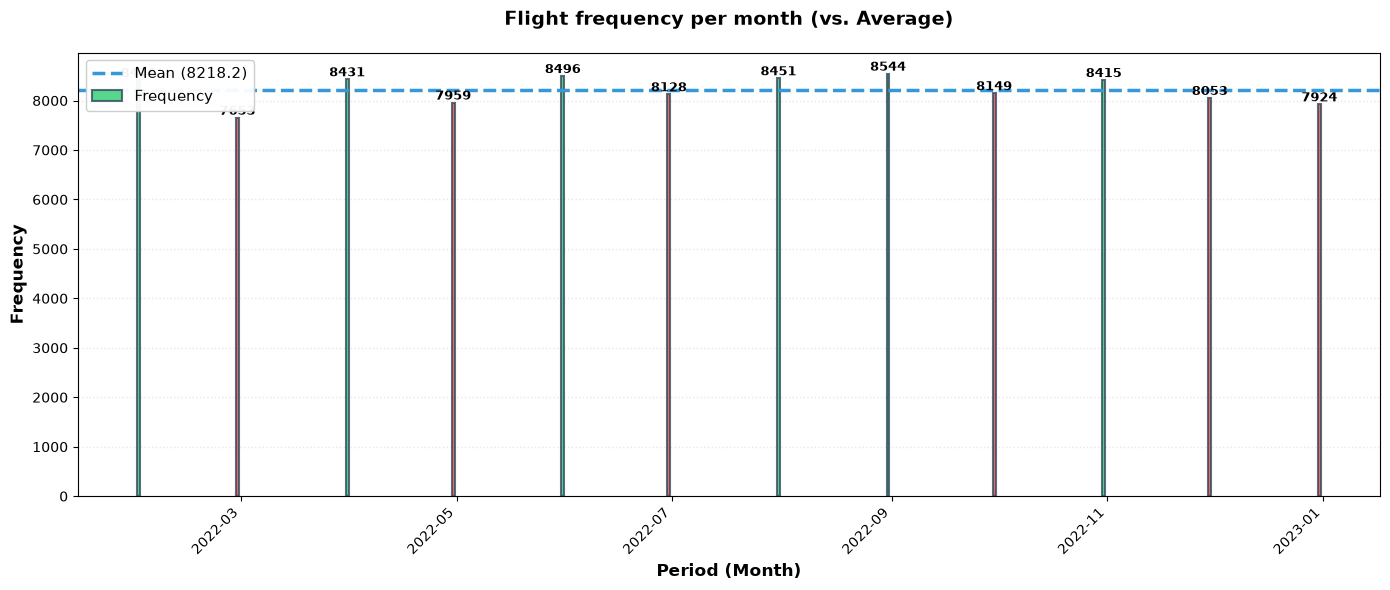


Frequency Statistics
Mean: 8218.25
Min:  7653
Max:  8544
Std:  281.89

Above-average months: 6
Below-average months: 6



In [29]:
# Setting the graph
fig, ax = plt.subplots(figsize=(14, 6))
 
# Plot bars with conditional colors
bar = ax.bar(
    freq_df_final['Departure Date'],
    freq_df_final['frequency'],
    color=freq_df_final['color'],
    alpha=0.8,
    edgecolor='#34495e',
    linewidth=1.5,
    label='Frequency'
)
 
# Plot average line
ax.axhline(y=average, color='#3498db', linestyle='--', linewidth=2.5, label=f'Mean ({average:.1f})')
 
# Customize the chart
ax.set_xlabel('Period (Month)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Flight frequency per month (vs. Average)', fontsize=14, fontweight='bold', pad=20)
 
# Rotate X-axis labels for better readability.
plt.xticks(rotation=45, ha='right')
 
# Add legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
 
# Add a grid for better readability.
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
ax.set_axisbelow(True)
 
# Add values to the bars (optional)
for bar, value in zip(bar, freq_df_final['frequency']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height,
        f'{int(value)}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
 
# Adjust layout
plt.tight_layout()
 
# Show graph
plt.show()
 
# Print statistics
print(f"\n{'='*50}")
print(f"Frequency Statistics")
print(f"{'='*50}")
print(f"Mean: {average:.2f}")
print(f"Min:  {freq_df_final['frequency'].min()}")
print(f"Max:  {freq_df_final['frequency'].max()}")
print(f"Std:  {freq_df_final['frequency'].std():.2f}")
print(f"\nAbove-average months: {(freq_df_final['frequency'] >= average).sum()}")
print(f"Below-average months: {(freq_df_final['frequency'] < average).sum()}")
print(f"{'='*50}\n")

In [30]:
# Grouping data per month split in Flight Status 
freq_df_final = df_final.groupby(
    [pd.Grouper(key='Departure Date', freq='ME'),'Flight Status']).size().reset_index(name='frequency')
print(freq_df_final.head(5))

  Departure Date Flight Status  frequency
0     2022-01-31     Cancelled       2747
1     2022-01-31       Delayed       2868
2     2022-01-31       On Time       2801
3     2022-02-28     Cancelled       2565
4     2022-02-28       Delayed       2537


In [31]:
average = freq_df_final['frequency'].mean()
average

np.float64(2739.4166666666665)


Global Average: 2739.42
Color per Flight Status:
  • On Time: #2ecc71
  • Delayed: #f39c12
  • Cancelled: #e74c3c



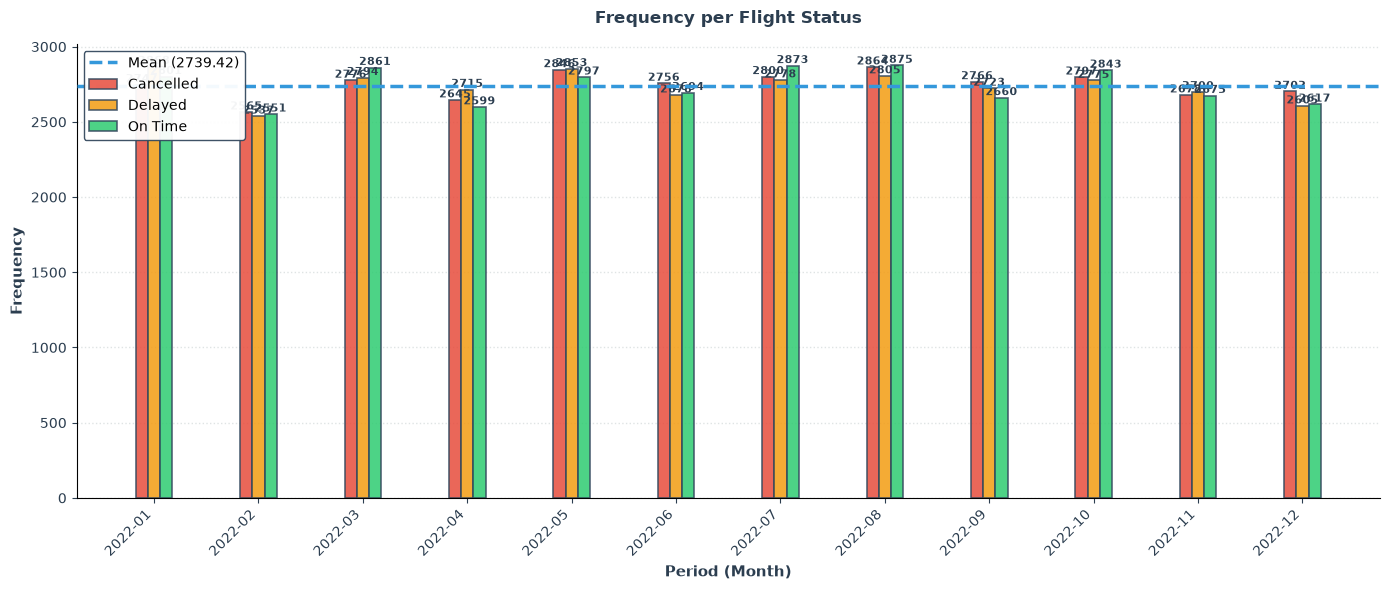


STATISTICS BY FLIGHT STATUS

📊 Cancelled
   Mean:              2745.17
   Total:               32942 ( 33.4%)
   Min:                  2565
   Max:                  2864
   Std Dev:            85.47

📊 Delayed
   Mean:              2735.92
   Total:               32831 ( 33.3%)
   Min:                  2537
   Max:                  2868
   Std Dev:            97.49

📊 On Time
   Mean:              2737.17
   Total:               32846 ( 33.3%)
   Min:                  2551
   Max:                  2875
   Std Dev:           117.36




In [32]:
# Set colors for each flight status
color_status = {
    'On Time': '#2ecc71',      # Green
    'Delayed': '#f39c12',      # Orange
    'Cancelled': '#e74c3c'     # Red
}
 
print(f"\n{'='*70}")
print(f"Global Average: {average:.2f}")
print(f"{'='*70}")
print(f"Color per Flight Status:")
for status, color in color_status.items():
    print(f"  • {status}: {color}")
print(f"{'='*70}\n")
 
# Get unique flight statuses (sorted for consistency)
flight_statuses = sorted(freq_df_final['Flight Status'].unique())
 
# Configure bar positions
dates_unique = sorted(freq_df_final['Departure Date'].unique())
x = np.arange(len(dates_unique))
width = 0.35 / len(flight_statuses) if len(flight_statuses) > 1 else 0.35
 
# Create figure
fig, ax = plt.subplots(figsize=(14, 6))
 
# Plot bars for each Flight Status
for status_idx, flight_status in enumerate(flight_statuses):
    data_status = freq_df_final[freq_df_final['Flight Status'] == flight_status]
 
    # Create a dictionary for date mapping
    data_map = dict(zip(data_status['Departure Date'], data_status['frequency']))
 
    # Values for each date
    values = [data_map.get(date, 0) for date in dates_unique]
 
    # Get Flight Status color
    color_bar = color_status.get(flight_status, '#95a5a6')
 
    # Bar position
    positions = x + (status_idx * width)
 
    # Plot bars
    bars = ax.bar(
        positions,
        values,
        width,
        label=flight_status,
        color=color_bar,
        alpha=0.85,
        edgecolor='#34495e',
        linewidth=1.2
    )
 
    # Add values on bars
    for bar, value in zip(bars, values):
        if value > 0:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{int(value)}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                color='#2c3e50'
            )
 
# Plot average line
ax.axhline(
    y=average,
    color='#3498db',
    linestyle='--',
    linewidth=2.5,
    label=f'Mean ({average:.2f})',
    zorder=3
)
 
# Configure X-axis
ax.set_xticks(x + (width * (len(flight_statuses)-1) / 2))
ax.set_xticklabels([d.strftime('%Y-%m') for d in dates_unique], rotation=45, ha='right')
 
# Labels and title
ax.set_xlabel('Period (Month)', fontsize=11, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold', color='#2c3e50')
ax.set_title('Frequency per Flight Status', fontsize=12, fontweight='bold', pad=15, color='#2c3e50')
 
# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95, edgecolor='#34495e')
 
# Grid
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1, color='#95a5a6')
ax.set_axisbelow(True)
 
# Adjust style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')
 
plt.tight_layout()
plt.show()
 
# ==========================================
# Statistics by Flight Status
# ==========================================
 
print(f"\n{'='*70}")
print(f"STATISTICS BY FLIGHT STATUS")
print(f"{'='*70}\n")
 
for status in sorted(freq_df_final['Flight Status'].unique()):
    data = freq_df_final[freq_df_final['Flight Status'] == status]['frequency']
    percentage = (data.sum() / freq_df_final['frequency'].sum()) * 100
 
    print(f"📊 {status}")
    print(f"   Mean:              {data.mean():7.2f}")
    print(f"   Total:             {data.sum():7.0f} ({percentage:5.1f}%)")
    print(f"   Min:               {data.min():7.0f}")
    print(f"   Max:               {data.max():7.0f}")
    print(f"   Std Dev:           {data.std():6.2f}")
    print()
 
print("="*70 + "\n")

In [33]:
# Extract the day of the week and create a pivot_table
df_final['Day of Week'] = pd.to_datetime(df_final['Departure Date']).dt.day_name()

# Arrange the days of the week correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
 
# Create a pivot table by day of the week
pivot_df = df_final.pivot_table(
    index='Day of Week',
    columns='Flight Status',
    values='Passenger ID',
    aggfunc='count'
)

In [34]:
# Reorder by days of the week
pivot_df = pivot_df.reindex(days_order)
 
# Create a table with metrics
pivot_metrics = pivot_df.copy()
 
# Add Out of Time column (Cancelled + Delayed)
pivot_metrics['Out of Time'] = (
    pivot_df.get('Cancelled', 0) + pivot_df.get('Delayed', 0)
)
 
# Add TOTAL column
pivot_metrics['TOTAL'] = pivot_df.sum(axis=1)
 
# Calculate Out of Time % (como número, não string)
pivot_metrics['Out of Time %'] = (
    pivot_metrics['Out of Time'] / pivot_metrics['TOTAL'] * 100
)
 
# Converter % de volta para string com formatação
pivot_metrics['Out of Time %'] = pivot_metrics['Out of Time %'].apply(
    lambda x: f'{x:.1f}%'
)
 
print(f"\n{'='*90}")
print(f"DELAYS BY DAY OF THE WEEK (Cancelled + Delayed)")
print(f"{'='*90}\n")
 
# Display table
display(pivot_metrics)
 
# Find worst day
pivot_temp = pivot_df.copy()
pivot_temp['Out of Time %'] = (
    (pivot_temp.get('Cancelled', 0) + pivot_temp.get('Delayed', 0)) / pivot_temp.sum(axis=1) * 100
)
worst_day = pivot_temp['Out of Time %'].idxmax()
worst_day_pct = pivot_temp['Out of Time %'].max()
 
# Summary statistics
print(f"\n{'='*90}")
print(f"SUMMARY PER WEEK")
print(f"{'='*90}\n")
 
for day in days_order:
    if day in pivot_metrics.index:
        row = pivot_metrics.loc[day]
        cancelled = pivot_df.loc[day, 'Cancelled'] if 'Cancelled' in pivot_df.columns else 0
        delayed = pivot_df.loc[day, 'Delayed'] if 'Delayed' in pivot_df.columns else 0
        on_time = pivot_df.loc[day, 'On Time'] if 'On Time' in pivot_df.columns else 0
        total = row['TOTAL']
        out_of_time_pct = row['Out of Time %']
 
        print(f"{day:12} | Total: {total:6.0f} | Cancelled: {cancelled:4.0f} | Delayed: {delayed:4.0f} | Out of Time: {out_of_time_pct}")
 
print(f"\n{'='*90}")
print(f"🔴 DAY WITH THE HIGHEST DELAY RATE: {worst_day} ({worst_day_pct:.1f}%)")
print(f"{'='*90}\n")


DELAYS BY DAY OF THE WEEK (Cancelled + Delayed)



Flight Status,Cancelled,Delayed,On Time,Out of Time,TOTAL,Out of Time %
Day of Week,,,,,,
Monday,4751,4700,4581,9451,14032,67.4%
Tuesday,4645,4757,4646,9402,14048,66.9%
Wednesday,4653,4610,4676,9263,13939,66.5%
Thursday,4757,4662,4808,9419,14227,66.2%
Friday,4831,4707,4689,9538,14227,67.0%
Saturday,4569,4649,4639,9218,13857,66.5%
Sunday,4736,4746,4807,9482,14289,66.4%



SUMMARY PER WEEK

Monday       | Total:  14032 | Cancelled: 4751 | Delayed: 4700 | Out of Time: 67.4%
Tuesday      | Total:  14048 | Cancelled: 4645 | Delayed: 4757 | Out of Time: 66.9%
Wednesday    | Total:  13939 | Cancelled: 4653 | Delayed: 4610 | Out of Time: 66.5%
Thursday     | Total:  14227 | Cancelled: 4757 | Delayed: 4662 | Out of Time: 66.2%
Friday       | Total:  14227 | Cancelled: 4831 | Delayed: 4707 | Out of Time: 67.0%
Saturday     | Total:  13857 | Cancelled: 4569 | Delayed: 4649 | Out of Time: 66.5%
Sunday       | Total:  14289 | Cancelled: 4736 | Delayed: 4746 | Out of Time: 66.4%

🔴 DAY WITH THE HIGHEST DELAY RATE: Monday (67.4%)




Global Average: 620.25
Color per Flight Status:
  • On Time: #2ecc71
  • Delayed: #f39c12
  • Cancelled: #e74c3c



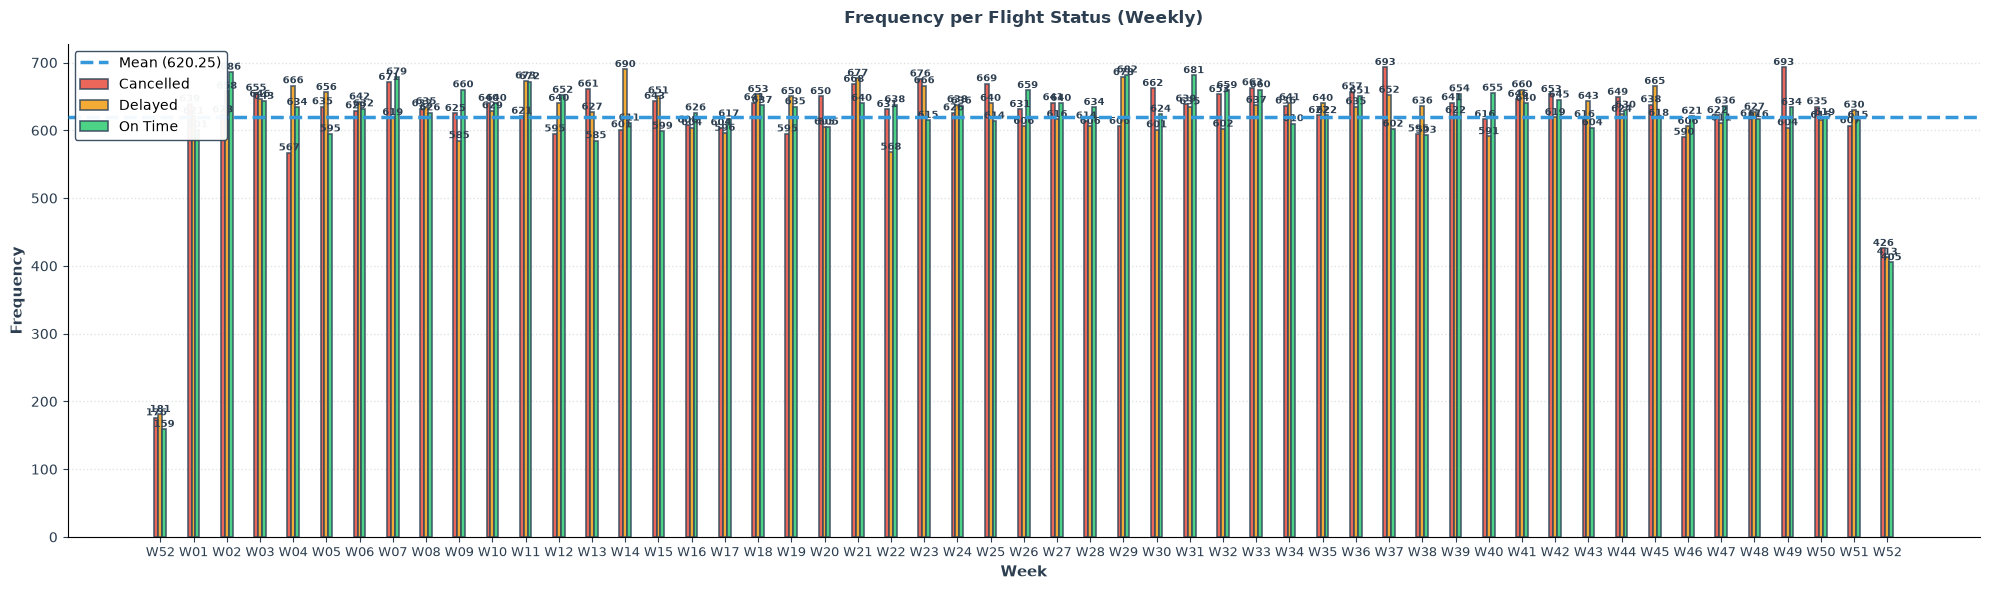


STATISTICS BY FLIGHT STATUS (WEEKLY)

📊 Cancelled
   Mean:               621.55
   Total:               32942 ( 33.4%)
   Min:                   176
   Max:                   693
   Std Dev:            73.32

📊 Delayed
   Mean:               619.45
   Total:               32831 ( 33.3%)
   Min:                   181
   Max:                   690
   Std Dev:            73.00

📊 On Time
   Mean:               619.74
   Total:               32846 ( 33.3%)
   Min:                   159
   Max:                   686
   Std Dev:            75.57



In [35]:
# Source: Group by Departure Date (WEEKLY) and Flight Status
freq_df_final = df_final.groupby(
     [pd.Grouper(key='Departure Date', freq='W'),'Flight Status']).size().reset_index(name='frequency')
 
# Calculate global average
average = freq_df_final['frequency'].mean()
 
# Set colors for each flight status
color_status = {
    'On Time': '#2ecc71',      # Green
    'Delayed': '#f39c12',      # Orange
    'Cancelled': '#e74c3c'     # Red
}
 
print(f"\n{'='*70}")
print(f"Global Average: {average:.2f}")
print(f"{'='*70}")
print(f"Color per Flight Status:")
for status, color in color_status.items():
    print(f"  • {status}: {color}")
print(f"{'='*70}\n")
 
# Get unique flight statuses (sorted for consistency)
flight_statuses = sorted(freq_df_final['Flight Status'].unique())
 
# Configure bar positions
dates_unique = sorted(freq_df_final['Departure Date'].unique())
x = np.arange(len(dates_unique))
width = 0.35 / len(flight_statuses) if len(flight_statuses) > 1 else 0.35
 
# Create figure
fig, ax = plt.subplots(figsize=(20, 6))
 
# Plot bars for each Flight Status
for status_idx, flight_status in enumerate(flight_statuses):
    data_status = freq_df_final[freq_df_final['Flight Status'] == flight_status]
 
    # Create a dictionary for date mapping
    data_map = dict(zip(data_status['Departure Date'], data_status['frequency']))
 
    # Values for each date
    values = [data_map.get(date, 0) for date in dates_unique]
 
    # Get Flight Status color
    color_bar = color_status.get(flight_status, '#95a5a6')
 
    # Bar position
    positions = x + (status_idx * width)
 
    # Plot bars
    bars = ax.bar(
        positions,
        values,
        width,
        label=flight_status,
        color=color_bar,
        alpha=0.85,
        edgecolor='#34495e',
        linewidth=1.2
    )
 
    # Add values on bars
    for bar, value in zip(bars, values):
        if value > 0:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{int(value)}',
                ha='center',
                va='bottom',
                fontsize=7,
                fontweight='bold',
                color='#2c3e50'
            )
 
# Plot average line
ax.axhline(
    y=average,
    color='#3498db',
    linestyle='--',
    linewidth=2.5,
    label=f'Mean ({average:.2f})',
    zorder=3
)
 
# Configure X-axis with week labels (apenas Week XX)
week_labels = [f"W{d.isocalendar().week:02d}" for d in dates_unique]
ax.set_xticks(x + (width * (len(flight_statuses)-1) / 2))
ax.set_xticklabels(week_labels, rotation=0, ha='center', fontsize=9)
 
# Labels and title
ax.set_xlabel('Week', fontsize=11, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold', color='#2c3e50')
ax.set_title('Frequency per Flight Status (Weekly)', fontsize=12, fontweight='bold', pad=15, color='#2c3e50')
 
# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95, edgecolor='#34495e')
 
# Grid
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1, color='#95a5a6')
ax.set_axisbelow(True)
 
# Adjust style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#2c3e50')
 
plt.tight_layout()
plt.show()
 
# ==========================================
# Statistics by Flight Status
# ==========================================
 
print(f"\n{'='*70}")
print(f"STATISTICS BY FLIGHT STATUS (WEEKLY)")
print(f"{'='*70}\n")
 
for status in sorted(freq_df_final['Flight Status'].unique()):
    data = freq_df_final[freq_df_final['Flight Status'] == status]['frequency']
    percentage = (data.sum() / freq_df_final['frequency'].sum()) * 100
 
    print(f"📊 {status}")
    print(f"   Mean:              {data.mean():7.2f}")
    print(f"   Total:             {data.sum():7.0f} ({percentage:5.1f}%)")
    print(f"   Min:               {data.min():7.0f}")
    print(f"   Max:               {data.max():7.0f}")
    print(f"   Std Dev:           {data.std():6.2f}")
    print()

In [36]:
# 1. Grouping data per airport
freq_df_final = df_final_clean[df_final_clean['Flight Status']!='On Time'].groupby('Airport Continent', as_index=False)['count'].sum()

# 2. Sort in descending order and calculate the running total.
freq_df_final = freq_df_final.sort_values(by='count', ascending=False).reset_index(drop=True)
freq_df_final['Pct_Acumulated'] = ( freq_df_final["count"].cumsum() / freq_df_final["count"].sum()) * 100
#freq_df_final_pareto = freq_df_final[freq_df_final["Pct_Acumulated"].shift(1).fillna(0) < 80].copy()

freq_df_final

,Airport Continent,count,Pct_Acumulated
0,NAM,21264,32.634018
1,AS,12352,51.590724
2,OC,9148,65.630228
3,EU,8237,78.271613
4,AF,7213,89.341457
5,SAM,6945,100.000000


In [37]:
## Airport Name per Flight Status
pivot_df = df_final_clean.pivot_table(index = ['Airport Name','Airport Continent'],
               columns = 'Flight Status',
               values = 'Passenger ID',
               aggfunc = 'count')

In [38]:
# Create a table with metrics
pivot_metrics = pivot_df.copy()
 
# Add Out of Time column
pivot_metrics['Out of Time'] = (
    pivot_df.get('Cancelled',0) + pivot_df.get('Delayed',0)
)

# Add TOTAL column
pivot_metrics['TOTAL'] = pivot_df.sum(axis=1)

# Get top 10 detractors (by Out of Time %)
pivot_metrics['Out of Time %'] = (
    pivot_metrics['Out of Time'] / pivot_metrics['TOTAL'] * 100
)

# 2. Reset the index to work with it as a regular column.
pivot_metrics_reset = pivot_metrics.reset_index()

# 3. Sort by Out of Time % (descending) and then by TOTAL (descending)
top_detractors = pivot_metrics_reset.sort_values(
    by=['Out of Time %', 'TOTAL'],
    ascending=[False, False]
).head(20)

# 4. Convert % back to a formatted string
top_detractors['Out of Time %'] = top_detractors['Out of Time %'].apply(
    lambda x: f'{x:.1f}%'
)

# 5. Set index back to display
top_detractors = top_detractors.set_index('Airport Name')
 
print(f"\n{'='*90}")
print(f"TOP 20 DETRACTORS (Major Issues – Cancellations + Delays)")
print(f"{'='*90}\n")
 
# Display table
display(top_detractors)
 
# Summary statistics
print(f"\n{'='*90}")
print(f"SUMMARY PER TOP 20 DETRACTORS")
print(f"{'='*90}\n")
 
total_general = top_detractors['TOTAL'].sum()
out_of_time_general = top_detractors['Out of Time'].sum()
pct_out_of_time = (out_of_time_general / total_general * 100)
 
print(f"Total Passengers:                   {total_general:8.0f}")
print(f"Out of Time (Cancellations/Delays): {out_of_time_general:8.0f}")
print(f"Out-of-Time Percentage:                {pct_out_of_time:6.2f}%")
print(f"On Time:                        {total_general - out_of_time_general:8.0f} ({100-pct_out_of_time:6.2f}%)")
print(f"\n{'='*90}\n")


TOP 20 DETRACTORS (Major Issues – Cancellations + Delays)



Flight Status,Airport Continent,Cancelled,Delayed,On Time,Out of Time,TOTAL,Out of Time %
Airport Name,,,,,,,
Buka Airport,OC,11.0,6.0,NaN,17.0,17.0,100.0%
Førde Airport,EU,7.0,7.0,NaN,14.0,14.0,100.0%
Carutapera Airport,SAM,8.0,5.0,NaN,13.0,13.0,100.0%
Maimun Saleh Airport,AS,6.0,7.0,NaN,13.0,13.0,100.0%
Shaikh Zaid Airport,AS,7.0,6.0,NaN,13.0,13.0,100.0%
Jomsom Airport,AS,6.0,6.0,NaN,12.0,12.0,100.0%
Kabwum,OC,5.0,7.0,NaN,12.0,12.0,100.0%
Sudbury Airport,NAM,8.0,4.0,NaN,12.0,12.0,100.0%
Tau Airport,OC,8.0,4.0,NaN,12.0,12.0,100.0%



SUMMARY PER TOP 20 DETRACTORS

Total Passengers:                        239
Out of Time (Cancellations/Delays):      239
Out-of-Time Percentage:                100.00%
On Time:                               0 (  0.00%)




### Overral Statistics

<Axes: title={'center': 'Age of Passengers'}, xlabel='Age', ylabel='Count'>

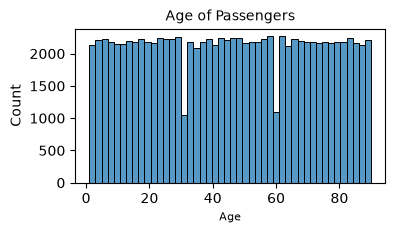

In [39]:
# Histogram graph from Age Passengers
fig = sns.histplot(df_final['Age'])
fig.figure.set_size_inches(4, 2)
fig.set_title('Age of Passengers', fontsize=10)
fig.set_xlabel('Age', fontsize=8)
fig

In [40]:
df_final['Gender'].value_counts(normalize=True).mul(100).round(2)

Gender
Male      50.29
Female    49.71
Name: proportion, dtype: float64

In [41]:
df_final['Age_Range'].value_counts(normalize=True).mul(100).round(2)

Age_Range
Adult      46.85
Elderly    34.35
Young      18.81
Name: proportion, dtype: float64

In [42]:
cross_analysis = pd.crosstab(
    df_final['Age_Range'], 
    df_final['Gender'], 
    normalize='index'
).mul(100).round(2)

print(cross_analysis)

Gender     Female   Male
Age_Range               
Adult       49.81  50.19
Elderly     49.69  50.31
Young       49.49  50.51


In [43]:
df_final['Airport Continent'].value_counts(normalize=True).mul(100).round(2)

Airport Continent
NAM    32.48
AS     18.90
OC     14.06
EU     12.51
AF     11.18
SAM    10.87
Name: proportion, dtype: float64

In [44]:
df_final_clean['Airport Continent'].value_counts(normalize=True).mul(100).round(2)

Airport Continent
NAM    32.58
AS     19.01
OC     14.03
EU     12.57
AF     11.14
SAM    10.66
Name: proportion, dtype: float64

In [45]:
df_final_clean['Continent Destination Code'].value_counts(normalize=True).mul(100).round(2)

Continent Destination Code
NAM      33.17
AS       16.92
OC       14.10
AF       10.83
EU       10.83
SAM       9.63
EU/AS     3.30
N/A       0.92
AF/AS     0.31
Name: proportion, dtype: float64

In [46]:
df_final_clean['Country Name'].value_counts(normalize=True).mul(100).round(2)

Country Name
United States       22.56
Australia            6.43
Canada               5.48
Brazil               4.54
Papua New Guinea     4.11
                    ...  
Nauru                0.01
Andorra              0.01
Monaco               0.01
Palau                0.01
Jersey               0.00
Name: proportion, Length: 235, dtype: float64

In [47]:
df_final_clean['Country Destination Name'].value_counts(normalize=True).mul(100).round(2)

Country Destination Name
United States       22.79
Australia            6.43
Canada               5.46
Papua New Guinea     4.13
Brazil               3.63
                    ...  
Monaco               0.01
Aland Islands        0.01
Wake Island          0.01
Palau                0.01
Jersey               0.00
Name: proportion, Length: 242, dtype: float64

In [48]:
df_final['Airport Name'].value_counts(normalize=True).mul(100).round(2)

Airport Name
San Pedro Airport       0.04
Santa Maria Airport     0.04
Böblingen Flugfeld      0.04
Santa Ana Airport       0.04
San Fernando Airport    0.03
                        ... 
San Luis Airport        0.00
J F Mitchell Airport    0.00
Camaxilo Airport        0.00
Falcon State Airport    0.00
Hiroshima Airport       0.00
Name: proportion, Length: 9062, dtype: float64

In [49]:
df_final_clean['Arrival Airport'].value_counts(normalize=True).mul(100).round(2)

Arrival Airport
0      0.87
JNB    0.04
PHM    0.04
MPT    0.03
PCO    0.03
       ... 
IPI    0.00
BQU    0.00
CXM    0.00
FAL    0.00
HIJ    0.00
Name: proportion, Length: 8940, dtype: float64

In [50]:
df_final['Flight Status'].value_counts(normalize=True).mul(100).round(2)

Flight Status
Cancelled    33.40
On Time      33.31
Delayed      33.29
Name: proportion, dtype: float64

In [51]:
cross_analysis = pd.crosstab(
    df_final['Continent Destination Code'], 
    df_final['Flight Status'], 
    normalize='index'
).mul(100).round(2)

print(cross_analysis)

Flight Status               Cancelled  Delayed  On Time
Continent Destination Code                             
AF                              33.33    32.97    33.70
AF/AS                           29.97    36.16    33.88
AS                              33.33    33.02    33.65
EU                              32.93    34.42    32.65
EU/AS                           34.43    32.20    33.37
N/A                             32.39    34.79    32.82
NAM                             33.40    33.34    33.26
OC                              33.31    33.41    33.27
SAM                             34.14    32.65    33.21


### Origin and Destination Analysis

In [2]:
# Grouping per month and split by Flight Status, Airport Continent and Continent Destination Code
freq_df_final = (
    # Removing missing data
    df_final_clean.groupby(
        [
            pd.Grouper(key="Departure Date", freq="ME"),
            "Flight Status",
            "Airport Continent",
            "Continent Destination Code",
        ]
    )
    .size()
    .reset_index(name="frequency")
)
print(freq_df_final.head(5))

NameError: name 'df_final_clean' is not defined

In [ ]:
fig = px.sunburst(freq_df_final, path=['Flight Status', 'Airport Continent','Continent Destination Code'], values='frequency',
                  color='frequency', 
                  color_continuous_scale='RdBu',
                  color_continuous_midpoint=np.average(freq_df_final['frequency'], weights=freq_df_final['frequency']),
                  title= "Origin and Destination per Flight Status")
fig.show()

In [ ]:
## Origin and Destination per Flight Status
print(f"\n{'='*70}")
print(f"Pivot Table per Continent and Flight Status")
print(f"{'='*70}\n")

pivot_df = df_final.pivot_table(index = ['Airport Continent', 'Continent Destination Code'],
               columns = 'Flight Status',
               values = 'Passenger ID',
               aggfunc = {'Passenger ID':'count'})
pivot_df


Pivot Table per Continent and Flight Status



Flight Status                                 Cancelled  Delayed  On Time
Airport Continent Continent Destination Code                             
AF                AF                               3550     3515     3591
                  AF/AS                              68       89       72
                  AS                                  4        5        5
                  EU                                  9       14       17
                  EU/AS                               4        4        2
                  N/A                                 2        2        6
                  NAM                                14       19       19
                  SAM                                 6        6        7
AS                AF                                 12       10       12
                  AF/AS                              20       16       25
                  AS                               5511     5453     5557
                  EU                                 18       18       18
                  EU/AS                             610      584      569
                  NAM                                41       48       35
                  OC                                 19       16       15
                  SAM                                 4       15       11
EU                AF                                  3        3        3
                  AS                                  1        4        3
                  EU                               3447     3603     3421
                  EU/AS                             489      443      493
                  N/A                                 6        8        4
                  NAM                               145      113      135
                  OC                                  4        4        3
NAM               AF                                  6        5        5
                  AF/AS                               4        6        7
                  AS                                  3        2        5
                  EU                                 12        8        1
                  NAM                             10658    10665    10616
                  OC                                  4        6        4
                  SAM                                 6        4        6
OC                AS                                  5        3        2
                  NAM                                 6        3        1
                  OC                               4608     4628     4610
SAM               AS                                  8       14       14
                  EU                                 15       16       14
                  EU/AS                               7        7       12
                  N/A                               289      309      291
                  NAM                                25       23       37
                  OC                                  7        2        4
                  SAM                              3292     3138     3194

In [ ]:
## Origin and Destination per Flight Status
pivot_df = df_final.pivot_table(index = ['Airport Continent', 'Age_Range'],
               columns = 'Flight Status',
               values = 'Passenger ID',
               aggfunc = {'Passenger ID':'count'})

In [ ]:
average_global = pivot_df.stack().mean()
average_global

np.float64(1826.2777777777778)

In [ ]:
# Create a table with metrics
pivot_metrics = pivot_df.copy()
 
# Add TOTAL column
pivot_metrics['TOTAL'] = pivot_df.sum(axis=1)
 
# Add AVERAGE column
pivot_metrics['MEAN'] = pivot_df.mean(axis=1).apply(
    lambda x: f'{x:.2f}'.rstrip('0').rstrip('.')
)
 
# Add percentages for each flight status
# Ensure that the columns exist
status_cols = ['Cancelled', 'Delayed', 'On Time']
 
for status in status_cols:
    if status in pivot_df.columns:
        pivot_metrics[f'{status} %'] = (
            (pivot_df[status] / pivot_df.sum(axis=1)) * 100
        ).apply(lambda x: f'{x:.1f}%' if pd.notna(x) else 'N/A')
    else:
        pivot_metrics[f'{status} %'] = 'N/A'
 
print(f"\n{'='*80}")
print(f"Pivot Table per Continent and Flight Status")
print(f"Global Average: {average_global:.2f}")
print(f"{'='*80}\n")
 
# ==========================================
# Function to format the table with colors
# ==========================================
 
def apply_full_formatting(row):
    """
    Applies different formatting for each column type:
    - Status values (green/red colors)
    - Total (blue)
    - Average (light blue)
    - Percentages (colors based on status)
    """
    style = []
    colunas = row.index
 
    for col, val in row.items():
        # Flight Status Columns (Cancelled, Delayed, On Time)
        if col in ['Cancelled', 'Delayed', 'On Time']:
            if pd.isna(val):
                style.append('background-color: #ecf0f1')
            elif val >= average_global:
                style.append('background-color: #d5f4e6; color: #1e7e34; font-weight: bold')
            else:
                style.append('background-color: #fadbd8; color: #a93226; font-weight: bold')
 
        # TOTAL Column
        elif col == 'TOTAL':
            style.append('background-color: #3498db; color: white; font-weight: bold; text-align: center')
 
        # MEAN Column
        elif col == 'MEAN':
            style.append('background-color: #5dade2; color: white; font-weight: bold; text-align: center')
 
        # Percentage Column
        elif 'Cancelled' in col:
            style.append('background-color: #fadbd8; color: #a93226; font-weight: bold; text-align: center')
        elif 'Delayed' in col:
            style.append('background-color: #fdebd0; color: #b9860c; font-weight: bold; text-align: center')
        elif 'On Time' in col:
            style.append('background-color: #d5f4e6; color: #1e7e34; font-weight: bold; text-align: center')
        else:
            style.append('')
 
    return style
 
# Apply formatting
pivot_formated = pivot_metrics.style.apply(apply_full_formatting, axis=1)
 
print("Table with all Metrics:")
display(pivot_formated)
 
# ==========================================
# Show statistical summary
# ==========================================
 
print(f"\n{'='*80}")
print(f"STATISTICAL SUMMARY")
print(f"{'='*80}\n")
 
# Totais por status
print("TOTALS BY FLIGHT STATUS:")
print("-" * 80)
for status in status_cols:
    if status in pivot_df.columns:
        total = pivot_df[status].sum()
        percentage = (total / pivot_df.sum().sum()) * 100
        print(f"  {status:12} | Total: {total:6.0f} | Percentage: {percentage:6.2f}%")
 
print()
 
# Mean per status
print("AVERAGES BY FLIGHT STATUS:")
print("-" * 80)
for status in status_cols:
    if status in pivot_df.columns:
        mean = pivot_df[status].mean()
        print(f"  {status:12} | Mean: {mean:7.2f}")
 
print("\n" + "="*80 + "\n")


Pivot Table per Continent and Flight Status
Global Average: 1826.28

Table with all Metrics:



STATISTICAL SUMMARY

TOTALS BY FLIGHT STATUS:
--------------------------------------------------------------------------------
  Cancelled    | Total:  32942 | Percentage:  33.40%
  Delayed      | Total:  32831 | Percentage:  33.29%
  On Time      | Total:  32846 | Percentage:  33.31%

AVERAGES BY FLIGHT STATUS:
--------------------------------------------------------------------------------
  Cancelled    | Mean: 1830.11
  Delayed      | Mean: 1823.94
  On Time      | Mean: 1824.78




In [ ]:
## creating dummy variables from categorical variables to analyze correlation
df_final_dummies = pd.get_dummies(
    df_final[~df_final['Airport Name'].isin(invalid_airports)], 
    columns=['Flight Status', 'Airport Continent', 'Continent Destination Code'],
    drop_first=True)

df_final_dummies.head(3)

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Continents,...,Airport Continent_OC,Airport Continent_SAM,Continent Destination Code_AF/AS,Continent Destination Code_AS,Continent Destination Code_EU,Continent Destination Code_EU/AS,Continent Destination Code_N/A,Continent Destination Code_NAM,Continent Destination Code_OC,Continent Destination Code_SAM
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,North America,...,False,False,False,False,False,False,False,True,False,False
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,North America,...,False,False,False,False,False,False,False,True,False,False
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,Europe,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
columns = df_final_dummies.columns
print(columns)

Index(['Passenger ID', 'First Name', 'Last Name', 'Gender', 'Age',
       'Nationality', 'Airport Name', 'Airport Country Code', 'Country Name',
       'Continents', 'Departure Date', 'Arrival Airport', 'Pilot Name',
       'Age_Range', 'Airport Country Destination Code',
       'Country Destination Name', 'Continent Destination', 'count',
       'Day of Week', 'Flight Status_Delayed', 'Flight Status_On Time',
       'Airport Continent_AS', 'Airport Continent_EU', 'Airport Continent_NAM',
       'Airport Continent_OC', 'Airport Continent_SAM',
       'Continent Destination Code_AF/AS', 'Continent Destination Code_AS',
       'Continent Destination Code_EU', 'Continent Destination Code_EU/AS',
       'Continent Destination Code_N/A', 'Continent Destination Code_NAM',
       'Continent Destination Code_OC', 'Continent Destination Code_SAM'],
      dtype='str')


In [ ]:
columns = ['Flight Status_Delayed', 'Flight Status_On Time',
       'Airport Continent_AS', 'Airport Continent_EU', 'Airport Continent_NAM',
       'Airport Continent_OC', 'Airport Continent_SAM',
       'Continent Destination Code_AF/AS', 'Continent Destination Code_AS',
       'Continent Destination Code_EU', 'Continent Destination Code_EU/AS',
       'Continent Destination Code_N/A', 'Continent Destination Code_NAM',
       'Continent Destination Code_OC', 'Continent Destination Code_SAM']

df_final_corr = df_final_dummies[columns].corr()

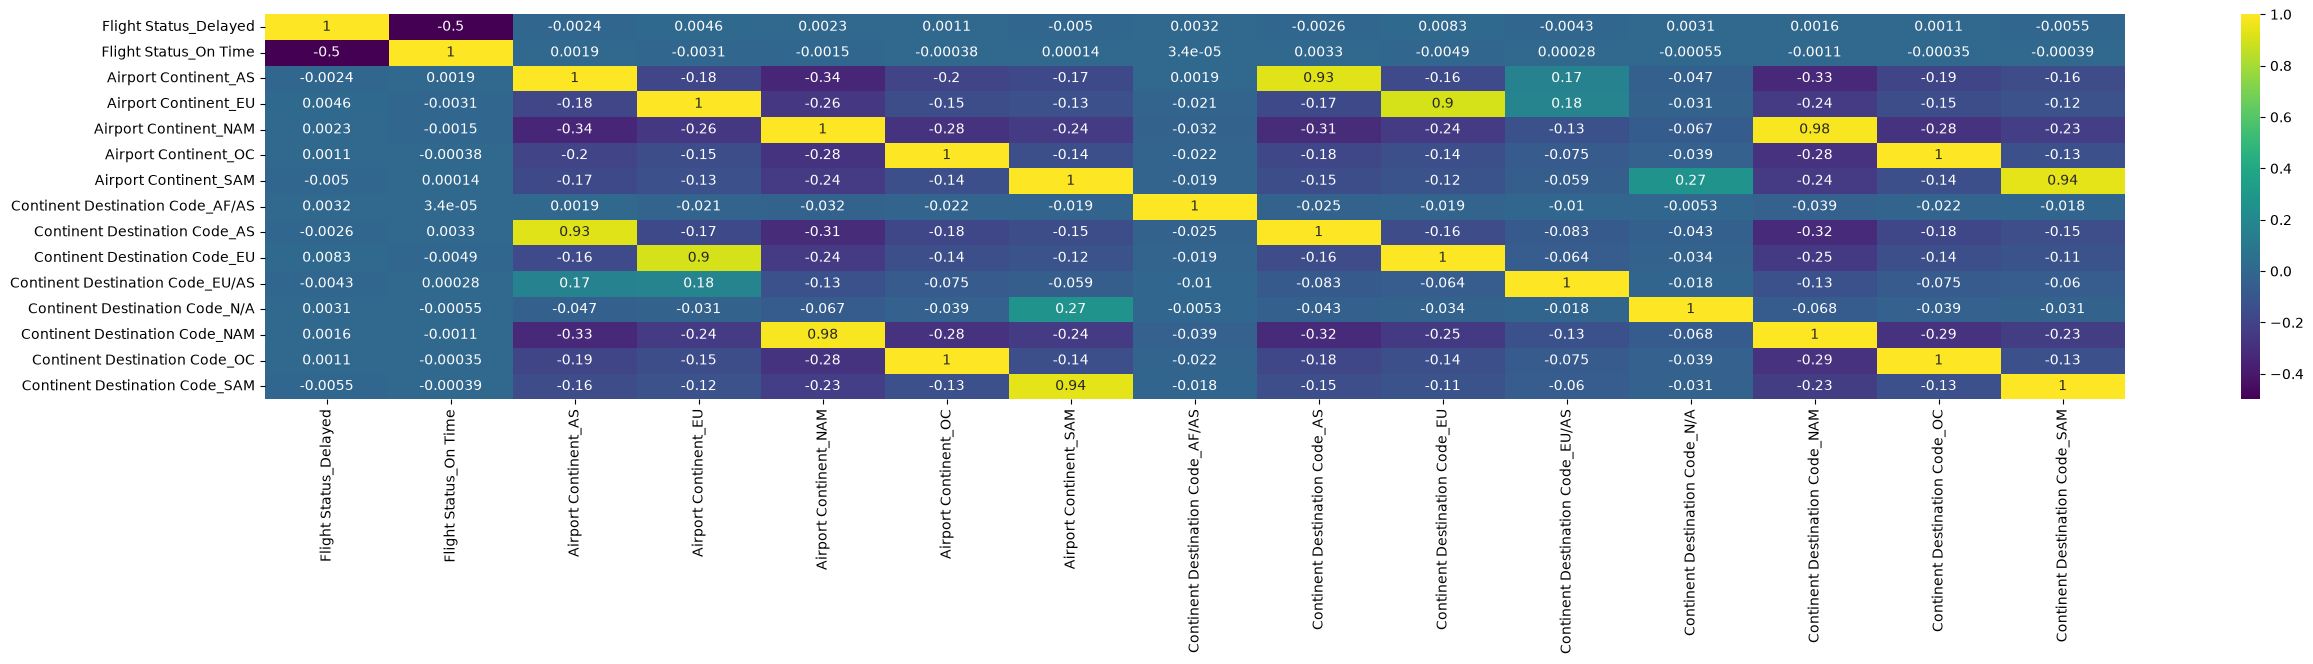

In [ ]:
plt.figure(figsize=(30,5))
sns.heatmap(df_final_corr, annot=True, cmap = plt.cm.viridis,
            annot_kws={'size':10})
plt.show()

# Insigths

### Data quality:

• The database contains data with unknown destinations: 926 rows with invalid airport codes ('0', '-', 'BR-', 'SB2', 'O62', 'TR7'), representing approximately 0.9% of the dataset. Of these, 94% contain the code '0', causing the greatest impact within the SAM continent (96%). <br>
• The database also contains 923 rows with data quality errors, where the same airport appears with different origins when it should maintain a 1-to-1 relationship. <br>
• If analysis is performed by continent or country, these rows should be excluded.

### Volume & Distribution Analysis:

• Flight volume is stable (~8,200 flights/month), suggesting predictable operations; however, the combined cancellation and delay rate of 33% is abnormal. <br>
• The volume trend is stationary, following a normal distribution with a mean of 8,218.25 flights per month and a standard deviation of 281.89. <br>
• When analyzing flight status by month or week, a normal distribution is observed between periods, as indicated by the trend, seasonal, and residual components in the time series analysis. <br>

### Performance by Day & Region:

• Monday shows the worst performance with 67.4% of cases out of time; not so far, Thursday has the lowest delay rate at 66.2%. <br>
• NAM represents the largest volume and SAM the smallest; when examining performance, both have 3–2 airports among the top 20 detractor airports. <br>
• The AS continent has the second-largest volume and accounts for 5 of the top 20 detractor airports. <br>
• Among the top 20 detractor airports, all have more than 10 flights and none achieved On Time performance.

### Flight Status & Route Patterns:

• A point of concern regarding flight status is that the proportion of volume remains consistent, with two-thirds of cases consistently showing Delayed or Canceled status. <br>
• It is clear when examining the "Origin and Destination per Flight Status" visualization that the majority of flights are domestic, occurring mostly within the same continent (82%). This is further confirmed by the positive correlation exceeding 0.9 between Origin and Destination. <br>
• Operations are region-fragmented, with the majority of flights occurring within the same continent.

# Suggestions/Actions

• Critical operational failures identified: Invest in a data-driven culture for root cause investigation by airport, beginning with Asia. <br>
• The company's next challenge will be to invest in acquiring new data, implementing real-time monitoring, and ensuring data quality integrity. <br>
• Implement predictive communication tools with customers and increase operational staffing during peak hours. <br>
• An opportunity for operational cost reduction exists through the consolidation of international routes, leveraging the dominance of domestic flights. <br>

### PHASE 2 - PREDICTIVE ANALYTICS (Requires Extended Dataset):

• Additional Data Needed: Historical weather patterns, aircraft maintenance logs, pilot experience levels, seasonal traffic variations. <br>
• Expected Outcome: Predict flight delays with 'xx%' + accuracy 'xx' days in advance. <br>
• Business Impact: '$xxxK' annual revenue recovery (based on 'x%' delay reduction). <br>
• Recommended Approach: Time series forecasting + ensemble methods (Random Forest + XGBoost).